# 🌊 BinWaves Duke (Reconstrction)

> **Inputs:**
> - Bathymetry file in `.nc` format, located in the `inputs/` folder.  
> - `Kp_coefficients.nc` file obtained with the `Propagation Notebook`.
> 
>
> **Outputs:**
> 
> 

### BinWaves Notebooks Overview

This Jupyter Notebook is the first of three in the **BinWaves** modeling workflow, following Cagigal et al., 2024 :

1. `BinWaves_Propagation.ipynb`  
2. `BinWaves_Reconstruction.ipynb`  
3. `BinWaves_Validation.ipynb`

---

#### Before You Start

Make sure you have:

- Installed the latest version of `bluemath-tk`:  
  ```bash
  pip install bluemath-tk[waves]
  ```
 
---

<details>
<summary><strong>📁 BinWaves_Propagation.ipynb</strong></summary>

This notebook constructs and runs the **library of pre-run cases** for all **monochromatic wave systems**.

</details>

---

<details open>
<summary><strong>📁 BinWaves_Reconstruction.ipynb</strong></summary>

This notebook reconstructs **wave conditions** using **offshore directional wave spectra**.

##### Requirements:

- Offshore wave spectrum data (e.g., **CAWCR** or **ERA5** datasets).

- **OPTIONAL 1**: Apply **satellite corrections** to the hindcast spectrum before running BinWaves using the `CalVal` tool in the BlueMath toolkit. An example is provided in the Jupyter Notebook **P00A_CalVal_Carolinas_CAWCR_4469.ipynb**.

- **OPTIONAL 2**: A **Super Point Spectrum** can be also used as input to the hindcast spectrum before running BinWaves. The `SuperPoint` aggregates the energy from a number of points (Wave Spectra) surrounding the study site (Cagigal et al., 2021).  An example is provided in the Jupyter Notebook **Super Point Computation** .

</details>

---

<details>
<summary><strong>📁 BinWaves_Validation.ipynb</strong></summary>

This notebook performs **validation** using **wave buoy data**, if available.

##### Requirements:

- Wave buoy data in a format compatible with BinWaves (if available).
- Some wave buoy data can be freely downloaded from:  
  🌊 [https://www.ndbc.noaa.gov/](https://www.ndbc.noaa.gov/)

- **NOTE:** You can use the `NDBC_buoy_data.ipynb` notebook to:
  - Download the buoy data.
  - Convert it into the appropriate format for BinWaves.

</details>

In [2]:
import warnings

warnings.filterwarnings("ignore")

In [3]:
import xarray as xr

whacs_spectra = xr.open_dataset(
    "inputs/alejandria_spec_WHACS.nc"
).rename({"__xarray_dataarray_variable__": "efth"})
whacs_spectra


# import xarray as xr

# cawcr_spectrum = xr.open_dataset(
#     "inputs/CAWCR_station_4469_spec_satellite_corrected_year_2023.nc"
# )
# cawcr_spectrum

<xarray.Dataset> Size: 5MB
Dimensions:   (time: 744, freq: 28, dir: 30)
Coordinates:
  * time      (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
    seapoint  int32 4B ...
  * freq      (freq) float64 224B 0.04118 0.0453 0.04983 ... 0.4908 0.5399
  * dir       (dir) float64 240B 84.0 72.0 60.0 48.0 ... 132.0 120.0 108.0 96.0
Data variables:
    efth      (time, freq, dir) float64 5MB ...

In [4]:
# Load all the gridded kps and reproject

kp_coeffs = xr.open_dataset("outputs/kp_coefficients.nc")
kp_coeffs

<xarray.Dataset> Size: 111MB
Dimensions:   (case_num: 336, site: 49, freq: 28, dir: 30)
Coordinates:
  * case_num  (case_num) int32 1kB 0 1 2 3 4 5 6 ... 329 330 331 332 333 334 335
  * site      (site) int32 196B 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
    coord_x   (site) float64 392B ...
    coord_y   (site) float64 392B ...
  * dir       (dir) float64 240B 12.0 24.0 36.0 48.0 ... 324.0 336.0 348.0 360.0
  * freq      (freq) float64 224B 0.0412 0.0453 0.0498 ... 0.4462 0.4908 0.5399
    lat       float64 8B ...
    lon       float64 8B ...
Data variables:
    kps       (case_num, site, freq, dir) float64 111MB ...

In [5]:
import numpy as np
from typing import Any, Dict, Tuple
import xarray as xr


def transform_Offshore_spectrum_WHACS(
    WHACS_spectrum: xr.Dataset,
    subset_parameters: Dict[str, Any],
    available_case_num: np.ndarray,
    fixed_direction: bool = False,
) -> Tuple[xr.Dataset, xr.Dataset]:
    """
    Transform the wave spectra from ERA5/CAWCAR format to binwaves format.

    Parameters
    ----------
    WHACS_spectrum : xr.Dataset
        The wave spectra dataset in ERA5/CAWCAR format.
        Must contain 'efth' variable and 'frequency'/'freq' and 'direction'/'dir' dimensions.
    subset_parameters : dict
        A dictionary containing parameters for the subset processing.
        Must contain:
        - 'dir' : array-like
            Direction values for each case.
        - 'freq' : array-like
            Frequency values for each case.
    available_case_num : ndarray
        The available case numbers to process.
    fixed_direction : bool, optional
        If True, skip direction convention transformation.
        Default is False.

    Returns
    -------
    ds : xr.Dataset
        The transformed wave spectra dataset with renamed dimensions.
    ds_case_num : xr.Dataset
        The wave spectra dataset in binwaves format with case_num dimension.

    Notes
    -----
    The function performs two main transformations:
    1. Renames dimensions from 'frequency'/'direction' to 'freq'/'dir' if needed
    2. Converts direction convention (unless fixed_direction=True)
    3. Projects spectra onto available case numbers
    """

    # First, reproject the wave spectra to the binwaves format
    # Only rename if the dimensions don't already have the correct names
    rename_dict = {}
    if "frequency" in WHACS_spectrum.dims:
        rename_dict["frequency"] = "freq"
    if "direction" in WHACS_spectrum.dims:
        rename_dict["direction"] = "dir"

    ds = WHACS_spectrum.rename(rename_dict) if rename_dict else WHACS_spectrum.copy()

    # direction convention coming from or going to
    if not fixed_direction:
        ds["efth"] = ds["efth"] * np.pi / 180.0
        ds["dir"] = ds["dir"] - 180.0
        ds["dir"] = np.where(ds["dir"] < 0, ds["dir"] + 360, ds["dir"])
        ds = ds.sortby("dir").sortby("freq")

    # Second, reproject into the available case numbers dimension
    case_num_spectra = []
    for case_num, case_dir, case_freq in zip(
        available_case_num,
        np.array(subset_parameters.get("dir"))[available_case_num],
        np.array(subset_parameters.get("freq"))[available_case_num],
    ):
        try:
            closest_case = (
                ds.efth.sel(freq=case_freq, method="nearest", tolerance=0.001)
                .sel(dir=case_dir, method="nearest", tolerance=2)
                .expand_dims({"case_num": [case_num]})
            )
            case_num_spectra.append(closest_case)
        except Exception as _e:
            # Add a zeros array if the case number is not available
            case_num_spectra.append(
                xr.zeros_like(ds.efth.isel(freq=0, dir=0)).expand_dims(
                    {"case_num": [case_num]}
                )
            )
    ds_case_num = (
        xr.concat(case_num_spectra, dim="case_num").drop_vars("dir").drop_vars("freq")
    )

    return ds, ds_case_num


In [6]:
import pandas as pd
from utils.operations import transform_Offshore_spectrum

model_parameters = pd.read_csv("ALEXANDRIA_SWAN_CASES/swan_cases.csv").to_dict(orient="list")

# Load interest spectra

offshore_spectra, offshore_spectra_case = transform_Offshore_spectrum(
    CAWCR_spectrum=whacs_spectra,
    subset_parameters=model_parameters,
    available_case_num=kp_coeffs.case_num.values,
    fixed_direction=True,  # True if efth is already in degrees(no radians) and cawcr direction for wavespectra  already corrected (from -> to)'
)
offshore_spectra_case


<xarray.DataArray 'efth' (case_num: 336, time: 744)> Size: 2MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(336, 744))
Coordinates:
  * case_num  (case_num) int32 1kB 0 1 2 3 4 5 6 ... 329 330 331 332 333 334 335
  * time      (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
    seapoint  int32 4B 2011723

In [7]:
# from matplotlib import pyplot as plt

# time_to_reconstruct = "2020-01-20"

# plt.pcolor(offshore_spectra.sel(time=time_to_reconstruct).dir, 
#          offshore_spectra.sel(time=time_to_reconstruct).freq,
#          offshore_spectra.sel(time=time_to_reconstruct).efth) 


In [8]:
# offshore_spectra = offshore_spectra.sortby("dir").drop_vars("seapoint")
# offshore_spectra = offshore_spectra.interp(dir=kp_coeffs.dir)

In [18]:
from bluemath_tk.waves.binwaves import reconstruc_spectra

time_to_reconstruct = "2020-01-20"

# Reconstruct spectra
reconstructed_onshore_spectra = reconstruc_spectra(
    offshore_spectra=offshore_spectra_case.sel(time=time_to_reconstruct),
    kp_coeffs=kp_coeffs.isel(site = range(2)),
)
reconstructed_onshore_spectra

<xarray.Dataset> Size: 323kB
Dimensions:   (site: 2, dir: 30, freq: 28, time: 24)
Coordinates:
  * site      (site) int32 8B 1 2
    coord_x   (site) float64 16B 28.6 29.05
    coord_y   (site) float64 16B 30.6 30.6
  * dir       (dir) float64 240B 12.0 24.0 36.0 48.0 ... 324.0 336.0 348.0 360.0
  * freq      (freq) float64 224B 0.0412 0.0453 0.0498 ... 0.4462 0.4908 0.5399
    lat       float64 8B 0.0
    lon       float64 8B 0.0
  * time      (time) datetime64[ns] 192B 2020-01-20 ... 2020-01-20T23:00:00
    seapoint  int32 4B 2011723
Data variables:
    kps       (time, site, freq, dir) float64 323kB 0.0 0.0 0.0 ... 0.0 0.0 0.0

(<Figure size 1500x600 with 2 Axes>,
 <GeoAxes: xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>)

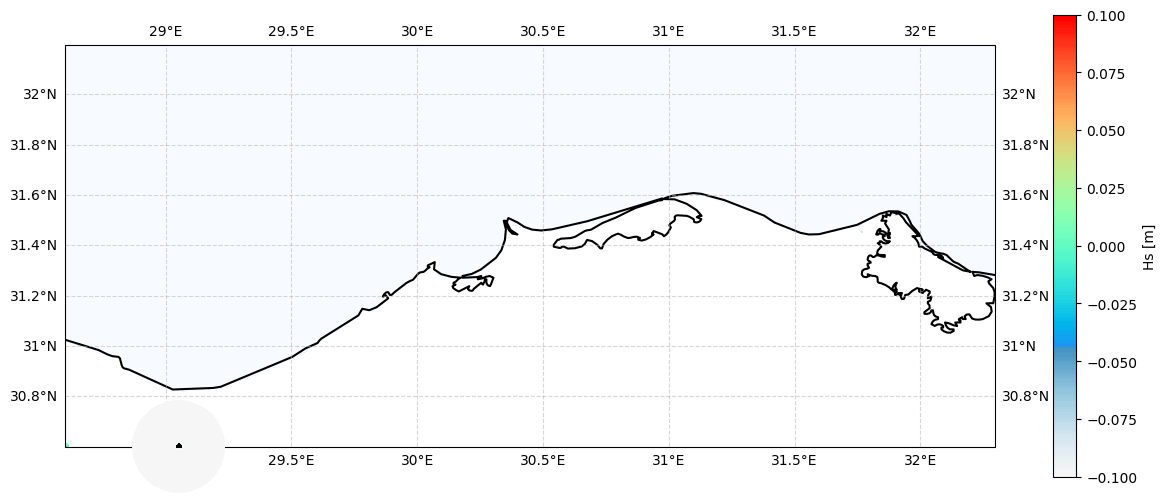

In [ ]:
from utils.plotting import plot_spectrum_in_coastline

time_to_plot = "2020-01-20 12:00"

# Plot the spectrum along the coastline
bathy = xr.open_dataset("inputs/EMODNET_alexandria.nc").elevation
plot_spectrum_in_coastline(
    bathy=bathy,
    reconstructed_onshore_spectra=reconstructed_onshore_spectra.rename({"kps": "kp"}),
    reconstruction_kps=kp_coeffs,
    offshore_spectra=offshore_spectra,
    time_to_plot=time_to_plot,
    sites_for_spectrum=list(range(-5, 0)),
)